In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from ollama_model import OllamaModel
from dataframe_creation import DataFrameCreator
from compute_statistics import compute_f1_and_hallucination
from pathlib import Path
import time

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
system_prompt = (
  "You are a strict OCR engine. You MUST return valid JSON and nothing else. "
  "Extract ONLY the player's LAST NAME, JERSEY NUMBER, and JERSEY COLOR from the image. "
  "Return JSON with keys: number (integer list or null), last_name (string list or null), color (string list or null), confidence (0..1)"
)

prompt = (
    "You are doing jersey OCR. Extract ONLY the player's LAST NAME, JERSEY NUMBER, and JERSEY COLOR.\n"
    "Return JSON with keys: number (integer list or null), last_name (string list or null), color (string list or null),"
    "confidence (0..1), raw_text (string). There can be multiple players in the image. Therefore, you must return a list "
    "of values for each JSON key even if only one player is detected.\n"
    "Rules:\n"
    "- last_name should be uppercase.\n"
    "- If unsure, set field to null and lower confidence.\n"
    "- Ignore sponsors/team name unless it is clearly the player's last name.\n"
)

In [3]:
image_folder = Path("images/")
image_files = [str(f) for f in image_folder.iterdir() if f.is_file()]

In [4]:
qwen_df_creator = DataFrameCreator()
qwen_model = OllamaModel(model_name="qwen3-vl")

start_time = time.time()

for img_path in image_files:
    qwen_output = qwen_model.extract_jersey_information(
        image_path=img_path,
        prompt=prompt
    )
    qwen_df_creator.append_df_from_output(qwen_output, img_path=img_path)
    print(f"Processed {img_path}")

qwen_df = qwen_df_creator.get_raw_df()
qwen_f1, qwen_hallucination_rate = compute_f1_and_hallucination(qwen_df)

end_time = time.time()
qwen_time = end_time - start_time

print(qwen_df)
print(f"Average time to process each image: {qwen_time / len(image_files):.2f} seconds")
print(f"F1 Score: {qwen_f1}")
print(f"Hallucination Rate: {qwen_hallucination_rate}")

Processed images/B63W2183-9-36-17-29-17-11-19-10-19-7-3-47.jpg
Processed images/_MG_3492-4-8-42-2-26-15.jpg
Processed images/_MG_3433-18-29-13.jpg
Processed images/_MG_3055-4-42-7-51-34-88.jpg
Processed images/_MG_3697-99.jpg
Processed images/B63W2443-17.jpg
Processed images/_MG_3580-22-18-25.jpg
Processed images/1129-10.jpg
Processed images/_MG_3656-4-29-12.jpg
Processed images/1L5A7414-10-15.jpg
                                               image  \
0  images/B63W2183-9-36-17-29-17-11-19-10-19-7-3-...   
1                 images/_MG_3492-4-8-42-2-26-15.jpg   
2                       images/_MG_3433-18-29-13.jpg   
3                images/_MG_3055-4-42-7-51-34-88.jpg   
4                             images/_MG_3697-99.jpg   
5                             images/B63W2443-17.jpg   
6                       images/_MG_3580-22-18-25.jpg   
7                                 images/1129-10.jpg   
8                        images/_MG_3656-4-29-12.jpg   
9                          images/1L5A7

In [7]:
gemma_df_creator = DataFrameCreator()
gemma_model = OllamaModel(model_name="gemma3:12b")

start_time = time.time()

for img_path in image_files:
    gemma_output = gemma_model.extract_jersey_information(
        image_path=img_path,
        prompt=prompt
    )
    gemma_df_creator.append_df_from_output(gemma_output, img_path=img_path)
    print(f"Processed {img_path}")

gemma_df = gemma_df_creator.get_raw_df()
gemma_f1, gemma_hallucination_rate = compute_f1_and_hallucination(gemma_df)

end_time = time.time()
gemma_time = end_time - start_time

print(gemma_df)
print(f"Average time to process each image: {gemma_time / len(image_files):.2f} seconds")
print(f"F1 Score: {gemma_f1}")
print(f"Hallucination Rate: {gemma_hallucination_rate}")

Processed images/B63W2183-9-36-17-29-17-11-19-10-19-7-3-47.jpg
Processed images/_MG_3492-4-8-42-2-26-15.jpg
Processed images/_MG_3433-18-29-13.jpg
Processed images/_MG_3055-4-42-7-51-34-88.jpg
Processed images/_MG_3697-99.jpg
Processed images/B63W2443-17.jpg
Processed images/_MG_3580-22-18-25.jpg
Processed images/1129-10.jpg
Processed images/_MG_3656-4-29-12.jpg
Processed images/1L5A7414-10-15.jpg
                                               image  \
0  images/B63W2183-9-36-17-29-17-11-19-10-19-7-3-...   
1                 images/_MG_3492-4-8-42-2-26-15.jpg   
2                       images/_MG_3433-18-29-13.jpg   
3                images/_MG_3055-4-42-7-51-34-88.jpg   
4                             images/_MG_3697-99.jpg   
5                             images/B63W2443-17.jpg   
6                       images/_MG_3580-22-18-25.jpg   
7                                 images/1129-10.jpg   
8                        images/_MG_3656-4-29-12.jpg   
9                          images/1L5A7

In [10]:
llava_df_creator = DataFrameCreator()
llava_model = OllamaModel(model_name="llava:13b")

start_time = time.time()

for img_path in image_files:
    llava_output = llava_model.extract_jersey_information(
        image_path=img_path,
        prompt=prompt
    )
    llava_df_creator.append_df_from_output(llava_output, img_path=img_path)
    print(f"Processed {img_path}")

llava_df = llava_df_creator.get_raw_df()
llava_f1, llava_hallucination_rate = compute_f1_and_hallucination(llava_df)

end_time = time.time()
llava_time = end_time - start_time

print(llava_df)
print(f"Average time to process each image: {llava_time / len(image_files):.2f} seconds")
print(f"F1 Score: {llava_f1}")
print(f"Hallucination Rate: {llava_hallucination_rate}")

Processed images/B63W2183-9-36-17-29-17-11-19-10-19-7-3-47.jpg
Processed images/_MG_3492-4-8-42-2-26-15.jpg
Processed images/_MG_3433-18-29-13.jpg
Processed images/_MG_3055-4-42-7-51-34-88.jpg
Processed images/_MG_3697-99.jpg
Processed images/B63W2443-17.jpg
Processed images/_MG_3580-22-18-25.jpg
Processed images/1129-10.jpg
Processed images/_MG_3656-4-29-12.jpg
Processed images/1L5A7414-10-15.jpg
                                               image   number  \
0  images/B63W2183-9-36-17-29-17-11-19-10-19-7-3-...   [None]   
1                 images/_MG_3492-4-8-42-2-26-15.jpg   [None]   
2                       images/_MG_3433-18-29-13.jpg  [8, 12]   
3                images/_MG_3055-4-42-7-51-34-88.jpg     [28]   
4                             images/_MG_3697-99.jpg   [None]   
5                             images/B63W2443-17.jpg   [None]   
6                       images/_MG_3580-22-18-25.jpg   [None]   
7                                 images/1129-10.jpg     [10]   
8             

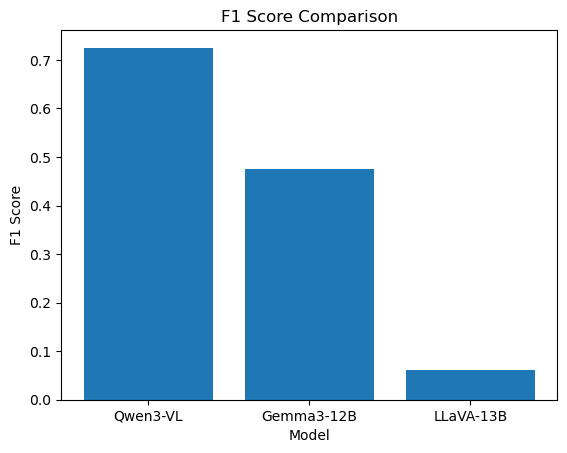

In [12]:
labels = ['Qwen3-VL', 'Gemma3-12B', 'LLaVA-13B']

f1_values = [qwen_f1, gemma_f1, llava_f1]

plt.bar(labels, f1_values)
plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.title('F1 Score Comparison')
plt.show()

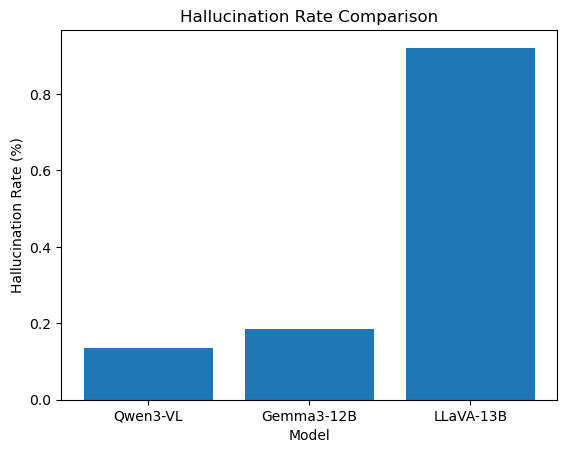

In [13]:
hallucination_values = [qwen_hallucination_rate, gemma_hallucination_rate, llava_hallucination_rate]

plt.bar(labels, hallucination_values)
plt.xlabel('Model')
plt.ylabel('Hallucination Rate (%)')
plt.title('Hallucination Rate Comparison')
plt.show()

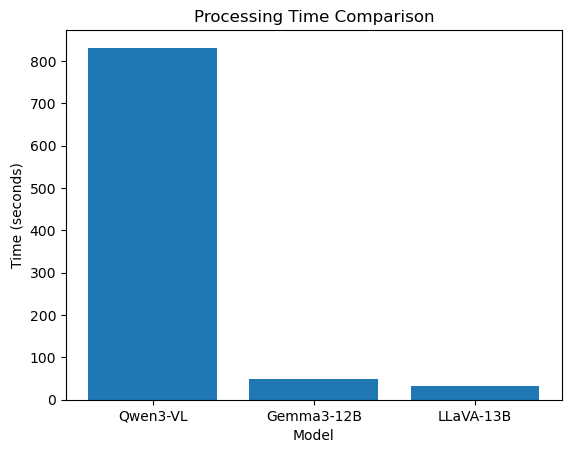

In [14]:
time_values = [qwen_time, gemma_time, llava_time]

plt.bar(labels, time_values)
plt.xlabel('Model')
plt.ylabel('Time (seconds)')
plt.title('Processing Time Comparison')
plt.show()